In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/raw/telecom_churn.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print("\n" + "="*60)
print("Dataset loaded successfully!")

Dataset Shape: (7043, 21)
Total Rows: 7,043
Total Columns: 21

Dataset loaded successfully!


In [3]:
# Display first 5 rows
print("First 5 rows of the dataset:\n")
df.head()

First 5 rows of the dataset:



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Get detailed information about the dataset
print("Dataset Information:")
print("="*60)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [5]:
# Check for missing values
print("Missing Values Analysis:")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("✅ No missing values found!")

Missing Values Analysis:
✅ No missing values found!


In [6]:
# Get statistical summary of numerical columns
print("Statistical Summary of Numerical Features:")
print("="*60)
df.describe()

Statistical Summary of Numerical Features:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn Distribution:

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


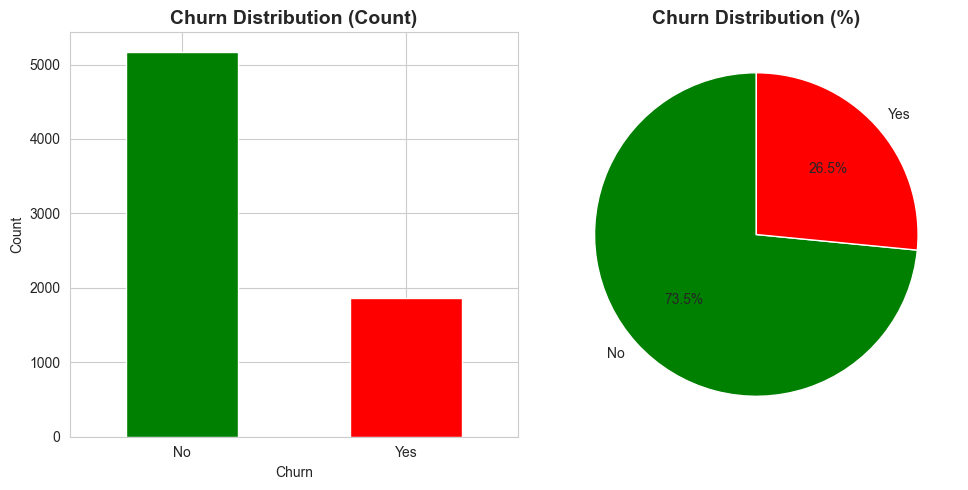


💡 Insight: 26.5% of customers churned!


In [7]:
# Analyze the target variable
print("Churn Distribution:")
print("="*60)

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f"\nChurn Counts:")
print(churn_counts)
print(f"\nChurn Percentages:")
print(churn_pct)

# Visualize
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
churn_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        colors=['green', 'red'], startangle=90)
plt.title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: {churn_pct['Yes']:.1f}% of customers churned!")

Checking TotalCharges after conversion:
Data type: float64
Missing values: 11




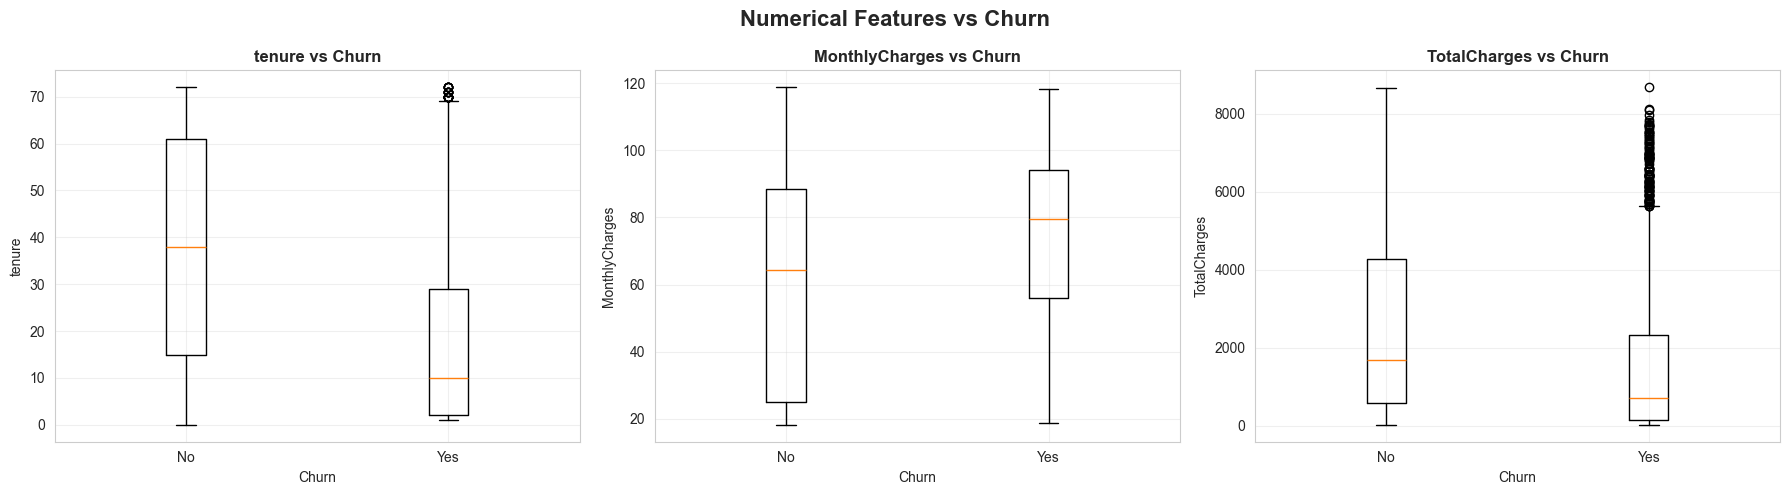

Key Observations:
- Compare the box plots between Churned (Yes) vs Not Churned (No)
- The line in the middle of each box is the MEDIAN
- Look for differences in median values and spread


In [10]:
# Cell 9: Analyze Numerical Features vs Churn

# First, let's fix TotalCharges data type issue
# Convert TotalCharges to numeric, replacing errors with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Checking TotalCharges after conversion:")
print(f"Data type: {df['TotalCharges'].dtype}")
print(f"Missing values: {df['TotalCharges'].isnull().sum()}")
print("\n" + "="*60 + "\n")

# Select numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    # Create box plot for each numerical feature
    # Group by Churn and plot
    churn_no = df[df['Churn'] == 'No'][col].dropna()
    churn_yes = df[df['Churn'] == 'Yes'][col].dropna()
    
    axes[i].boxplot([churn_no, churn_yes], labels=['No', 'Yes'])
    axes[i].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Numerical Features vs Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Observations:")
print("- Compare the box plots between Churned (Yes) vs Not Churned (No)")
print("- The line in the middle of each box is the MEDIAN")
print("- Look for differences in median values and spread")

In [11]:
# Cell: Check all columns
print("All columns in the dataset:")
print("="*60)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

print("\n" + "="*60)
print(f"Total columns: {len(df.columns)}")

All columns in the dataset:
 1. customerID
 2. gender
 3. SeniorCitizen
 4. Partner
 5. Dependents
 6. tenure
 7. PhoneService
 8. MultipleLines
 9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn

Total columns: 21


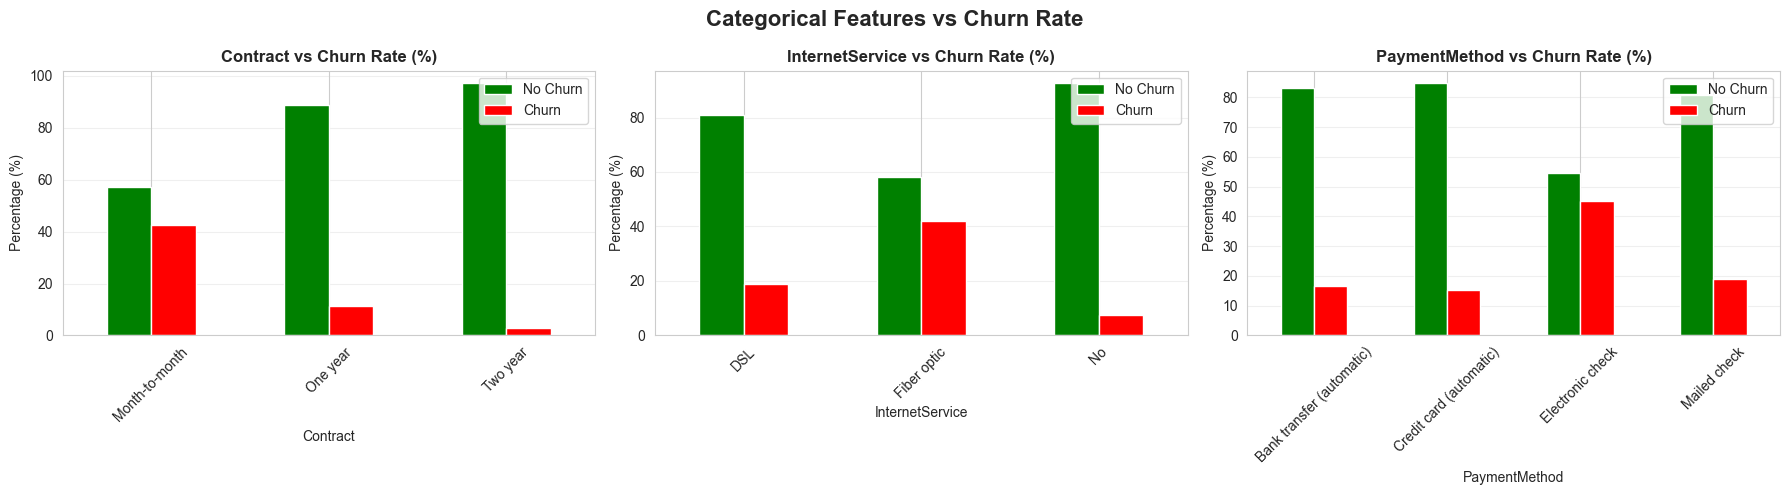

In [12]:
# Cell 10: Analyze Categorical Features vs Churn

# Select key categorical features
categorical_cols = ['Contract', 'InternetService', 'PaymentMethod']

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
    # Count churn by category
    churn_data = df.groupby([col, 'Churn']).size().unstack()
    
    # Calculate percentages
    churn_pct = churn_data.div(churn_data.sum(axis=1), axis=0) * 100
    
    # Plot
    churn_pct.plot(kind='bar', ax=axes[i], color=['green', 'red'])
    axes[i].set_title(f'{col} vs Churn Rate (%)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['No Churn', 'Churn'], loc='upper right')
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Rotate x-labels for readability
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Churn Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Cell 12: High-Risk Combination Analysis

# Find customers with ALL high-risk factors
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
]

print("HIGH-RISK CUSTOMER PROFILE:")
print("="*60)
print(f"Total customers matching profile: {len(high_risk)}")
print(f"Churn rate for this group: {(high_risk['Churn'] == 'Yes').sum() / len(high_risk) * 100:.1f}%")
print("\nFor comparison:")
print(f"Overall churn rate: {(df['Churn'] == 'Yes').sum() / len(df) * 100:.1f}%")

# Show some examples
print("\n" + "="*60)
print("Example high-risk customers:")
print(high_risk[['customerID', 'tenure', 'MonthlyCharges', 'Churn']].head(10))

HIGH-RISK CUSTOMER PROFILE:
Total customers matching profile: 1307
Churn rate for this group: 60.4%

For comparison:
Overall churn rate: 26.5%

Example high-risk customers:
    customerID  tenure  MonthlyCharges Churn
4   9237-HQITU       2           70.70   Yes
5   9305-CDSKC       8           99.65   Yes
8   7892-POOKP      28          104.80   Yes
14  5129-JLPIS      25          105.50    No
19  4183-MYFRB      21           90.05    No
26  6467-CHFZW      47           99.35   Yes
36  6047-YHPVI       5           69.70   Yes
38  5380-WJKOV      34          106.35   Yes
45  3714-NTNFO      49           84.50    No
47  7760-OYPDY       2           80.65   Yes


In [16]:
# Cell 13: Calculate Financial Impact

print("FINANCIAL IMPACT ANALYSIS")
print("="*60)

# High-risk customer analysis
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['PaymentMethod'] == 'Electronic check')
]

total_high_risk = len(high_risk)
churn_rate_high_risk = (high_risk['Churn'] == 'Yes').sum() / len(high_risk)
expected_churners = int(total_high_risk * churn_rate_high_risk)

# Calculate average revenue
avg_monthly_charge = high_risk['MonthlyCharges'].mean()
avg_customer_lifetime = 24  # months (industry average)

# Revenue calculations
revenue_per_customer = avg_monthly_charge * avg_customer_lifetime
total_at_risk_revenue = expected_churners * revenue_per_customer

print(f"\nHIGH-RISK SEGMENT ANALYSIS:")
print(f"   Total high-risk customers: {total_high_risk:,}")
print(f"   Current churn rate: {churn_rate_high_risk*100:.1f}%")
print(f"   Expected churners: {expected_churners:,} customers")
print(f"\nREVENUE IMPACT:")
print(f"   Average monthly charge: ${avg_monthly_charge:.2f}")
print(f"   Estimated customer lifetime value: ${revenue_per_customer:,.2f}")
print(f"   Total revenue at risk: ${total_at_risk_revenue:,.2f}")

print(f"\n IF WE REDUCE CHURN BY 20% (from 60.4% to 48.3%):")
saved_customers = int(expected_churners * 0.20)
saved_revenue = saved_customers * revenue_per_customer
print(f"   Customers saved: {saved_customers:,}")
print(f"   Revenue saved: ${saved_revenue:,.2f}")

print(f"\n IF WE REDUCE CHURN BY 50% (from 60.4% to 30.2%):")
saved_customers_50 = int(expected_churners * 0.50)
saved_revenue_50 = saved_customers_50 * revenue_per_customer
print(f"   Customers saved: {saved_customers_50:,}")
print(f"   Revenue saved: ${saved_revenue_50:,.2f}")

print("\n" + "="*60)
print(" THIS IS WHY YOUR ML MODEL MATTERS!")
print("   Even small improvements = HUGE revenue impact!")

FINANCIAL IMPACT ANALYSIS

HIGH-RISK SEGMENT ANALYSIS:
   Total high-risk customers: 1,307
   Current churn rate: 60.4%
   Expected churners: 789 customers

REVENUE IMPACT:
   Average monthly charge: $87.18
   Estimated customer lifetime value: $2,092.39
   Total revenue at risk: $1,650,896.11

 IF WE REDUCE CHURN BY 20% (from 60.4% to 48.3%):
   Customers saved: 157
   Revenue saved: $328,505.31

 IF WE REDUCE CHURN BY 50% (from 60.4% to 30.2%):
   Customers saved: 394
   Revenue saved: $824,401.86

 THIS IS WHY YOUR ML MODEL MATTERS!
   Even small improvements = HUGE revenue impact!


In [18]:
# Cell 14: Customer Risk Segmentation

print(" CUSTOMER RISK SEGMENTATION")
print("="*60)

# Define risk levels
def assign_risk_level(row):
    risk_score = 0
    
    # Contract (highest weight)
    if row['Contract'] == 'Month-to-month':
        risk_score += 3
    elif row['Contract'] == 'One year':
        risk_score += 1
    
    # Internet Service
    if row['InternetService'] == 'Fiber optic':
        risk_score += 2
    elif row['InternetService'] == 'DSL':
        risk_score += 1
    
    # Payment Method
    if row['PaymentMethod'] == 'Electronic check':
        risk_score += 2
    
    # Tenure
    if row['tenure'] < 12:
        risk_score += 2
    elif row['tenure'] < 24:
        risk_score += 1
    
    # Monthly Charges
    if row['MonthlyCharges'] > 80:
        risk_score += 1
    
    # Classify risk
    if risk_score >= 7:
        return 'Critical Risk'
    elif risk_score >= 5:
        return 'High Risk'
    elif risk_score >= 3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Apply risk segmentation
df['RiskLevel'] = df.apply(assign_risk_level, axis=1)

# Analyze segments
print("\nCustomer Distribution by Risk Level:")
print(df['RiskLevel'].value_counts().sort_index())

print("\nChurn Rate by Risk Level:")
for risk in ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']:
    segment = df[df['RiskLevel'] == risk]
    if len(segment) > 0:
        churn_rate = (segment['Churn'] == 'Yes').sum() / len(segment) * 100
        print(f"{risk:15} {len(segment):5} customers  →  {churn_rate:5.1f}% churn rate")

print("\n" + "="*60)
print("This shows our risk scoring system works!")

 CUSTOMER RISK SEGMENTATION

Customer Distribution by Risk Level:
RiskLevel
Critical Risk    2106
High Risk        1788
Low Risk         1798
Medium Risk      1351
Name: count, dtype: int64

Churn Rate by Risk Level:
Low Risk         1798 customers  →    2.3% churn rate
Medium Risk      1351 customers  →   10.7% churn rate
High Risk        1788 customers  →   26.6% churn rate
Critical Risk    2106 customers  →   57.3% churn rate

This shows our risk scoring system works!
